<a href="https://colab.research.google.com/github/aehaf988/Pro1/blob/main/project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project card


**The paper:** Alexandrov et al. 2013, "Signatures of mutational processes in human cancer," Nature 500:415–421. Introduced Signature 3 (SBS3), which is associated with defective homologous-recombination repair and BRCA1/2 loss.

**The reference profiles used:** SBS3 and a fixed background from COSMIC v3.6 (Nature 578:94–101). The background is the equal-weight average of SBS1, SBS2, SBS8, SBS13, SBS17a, SBS17b, SBS20.

**The data object:** Breast_genomes_mutational_catalog_96_subs.txt is a 96 × n_tumors matrix of mutation counts (96 trinucleotide channels × tumors). Plus COSMIC_v3.6_SBS_GRCh37.txt is a 96-channel mutational signatures.

**The random variable chosen:**  K  = the number of SBS3-shaped mutations in the cohort. It is obtained by projecting the catalog onto the SBS3 reference spectrum:  K=∑jr⊤SBS3cj .

**What the paper does:** The paper reports that SBS3 is enhanced in BRCA1/2-associated breast tumors and accounts for a substantial fraction of the mutational burden in a subset of patients. It presents per-sample signature exposures but does not attach a formal uncertainty model to the cohort-level SBS3 rate.


**The generative model proposed:**

K∼Poisson(N⋅θ)

K = number of SBS3-shaped mutations in the cohort
- K is a projection

N  = the total mutation count in the cohort

θ  = the SBS3 rate per mutation.

**Parameters:**

- N =	Total mutations in cohort	count (integer)	Fixed from data, not a free parameter
- θ =	SBS3 rate per mutation	dimensionless (often reported per million)	More SBS3-shaped mutations in simulated draws
- $\hat\theta$ = $K / N$

**Assumptions:**

Mutations accumulate as a Poisson process (independent, constant rate).
Ktotal  (the projection  r⊤SBS3c ) is treated as an integer count — it is in fact a weighted sum.
Ntotal  is fixed (we condition on observed burden), not random.
A single  θ  applies to the whole cohort (no heterogeneity).
rSBS3  is known without error.
No overdispersion.

**The forward simulation:** simulate(theta, N_total, rng) draws one Poisson observation. A histogram over 10,000 draws at  $\hat\theta$  visualizes the sampling distribution.

**The parameterization/fitting:** Closed-form MLE  $\hat\theta$ $=Ktotal/Ntotal$ . Exact 95% CI via chi-squared (Garwood). NLL curve confirms the MLE is at the minimum.

**What the model adds:**
K can be estimated from a Poisson model of N and theta.

It attaches a formal uncertainty model to the cohort-level SBS3 rate and a formal confidence interval to θ̂,. The original paper only reports per-sample SDS3 exposures. This model also provides a principled way to test whether observed counts are consistent with Poisson sampling.

**Model limitations / how it breaks:** See the final section. In brief: (i)  $K_{total}$  is a projection, not a count; (ii) real cohorts are underdispersed, so the CI is too wide; (iii) collapsing heterogeneity into one  θ  hides the BRCA1 subpopulation; (iv) conditioning on  N  ignores covariation between burden and signature fraction; (v) No formal likelihood comparison (e.g. negative binomial).

**AI usage**: AI was used to discuss ideas for the project and debugging codes.

## Imports and setup

In [ ]:
import numpy as np
import pandas as pd
import math
import scipy.stats as st
import matplotlib.pyplot as plt

CATALOG_URL = ('https://raw.githubusercontent.com/aehaf988/Pro1/main/data/'
               'Breast_genomes_mutational_catalog_96_subs.txt')
SIG_URL     = ('https://raw.githubusercontent.com/aehaf988/Pro1/main/data/'
               'COSMIC_v3.6_SBS_GRCh37.txt')

## Load data

The catalog is a 96 × n_tumors matrix of mutation counts. The signature file
contains 96-channel reference spectra for each COSMIC SBS signature.

In [ ]:
catalog = pd.read_csv(CATALOG_URL, sep='\t', index_col=0).astype(int)
sig     = pd.read_csv(SIG_URL,     sep='\t', index_col=0)

# Row alignment
assert list(sig.index) == list(catalog.index), "Row order mismatch"

# SBS3 reference spectrum (96,)
r_sbs3 = sig['SBS3'].values
r_sbs3 = r_sbs3 / r_sbs3.sum()

## Summary statistics: $N$ and $K$

$N$ is the total mutation count in the cohort (fixed).
$K$ is the projection of the catalog onto the SBS3 spectrum, summed over tumors.
The naive rate is $\hat{\theta} = K / N$.

Moved $K_{{total}}$ to the nearest integer $K_{{int}}$ before evaluating the likelihood

In [ ]:
# Total mutations in the cohort
N_total = int(catalog.values.sum())

# Total SBS3-shaped mutations in the cohort (dot product, then sum)
K_total = float((catalog.values.T @ r_sbs3).sum())
K_int = int(round(K_total))

print(f"N_total = {N_total:,} mutations across {catalog.shape[1]} tumors")
print(f"K_total = {K_total:,.1f} SBS3-shaped mutations")
print(f"naive rate = K/N = {K_total/N_total:.3e}  "
      f"({K_total/N_total*1e6:.2f} per million)")
print('K_int = ', K_int)

N_total = 647,692 mutations across 119 tumors
K_total = 7,818.6 SBS3-shaped mutations
naive rate = K/N = 1.207e-02  (12071.48 per million)
K_int =  7819


## Forward simulation

We draw one observation
for two candidate rates to show the effect of $\theta$.

In [ ]:
def simulate(theta, N_total, rng=None):
    """Draw one Poisson count with mean N_total * theta."""
    if rng is None:
        rng = np.random.default_rng()
    return rng.poisson(N_total * theta)

rng = np.random.default_rng(0)

# Simulate under two candidate rates
for theta in [1e-4, 5e-4]:
    K_sim = simulate(theta, N_total, rng)
    print(f"theta = {theta:.1e}  ->  K_sim = {K_sim:,}")



theta = 1.0e-04  ->  K_sim = 68
theta = 5.0e-04  ->  K_sim = 278


### Sampling distribution at $\hat{\theta}$

Histogram of 10,000 forward draws at the naive rate. The red line is the
observed $K_{\text{int}}$.

Under the model, K concentrates around N$\hat\theta$ where the observed K falls.

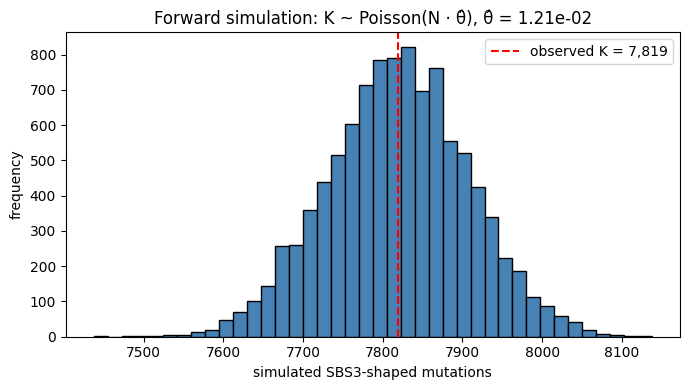

In [ ]:
theta_naive = K_total / N_total
K_sims = np.array([simulate(theta_naive, N_total, rng) for _ in range(10_000)])

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(K_sims, bins=40, color='steelblue', edgecolor='black')
ax.axvline(K_total, color='red', linestyle='--',
           label=f'observed K = {K_total:,.0f}')
ax.set_xlabel('simulated SBS3-shaped mutations')
ax.set_ylabel('frequency')
ax.set_title(f'Forward simulation: K ~ Poisson(N · θ̂), θ̂ = {theta_naive:.2e}')
ax.legend()
plt.tight_layout()
plt.show()

## Backward: parameter estimation and its CI

We estimate $\theta$ from the observed $K_{\text{int}}$ by maximum likelihood.
For a single Poisson rate the MLE has a closed form.

- MLE: $\hat\theta$ = $K_{\text{int}}$/$N_{\text{total}}$



In [ ]:
def poisson_log_pmf(k, lam):
    """log P(k | lam) = k log(lam) - lam - log(k!)."""
    assert isinstance(k, (int, np.integer)) and k>= 0
    return k * math.log(lam) - lam - math.lgamma(k+1)

def NLL(theta, K_obs_int, N_total):
    """Negative log-likelihood for a single Poisson rate."""
    lam = N_total * theta
    return -poisson_log_pmf(K_obs_int, lam)

theta_hat = K_int / N_total
print(f"theta_hat = {theta_hat:.4e}  "
      f"({theta_hat*1e6:.3f} SBS3 mutations per million)")


theta_hat = 1.2072e-02  (12072.096 SBS3 mutations per million)


### NLL curve

The negative log-likelihood as a function of $\theta$. The minimum should
coincide with $\hat{\theta}$.

- Curve: NLL= 0 at the minimum and the curve is plotted as a relative NLL(the y-axis is ΔNLL).

The NLL-curve is the model-implied uncertainty under a homogenous-Poisson assumption

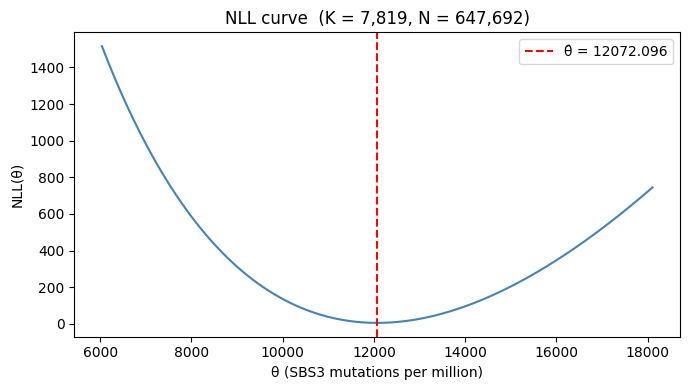

In [ ]:

thetas = np.linspace(0.5 * theta_hat, 1.5 * theta_hat, 400)
nlls   = [NLL(t, K_int, N_total) for t in thetas]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thetas * 1e6, nlls, color='steelblue')
ax.axvline(theta_hat * 1e6, color='red', linestyle='--',
           label=f'θ̂ = {theta_hat*1e6:.3f}')
ax.set_xlabel('θ (SBS3 mutations per million)')
ax.set_ylabel('NLL(θ)')
ax.set_title(f'NLL curve  (K = {K_total:,.0f}, N = {N_total:,})')
ax.legend()
plt.tight_layout()
plt.show()


### Exact 95% confidence interval

Point estimate: θ̂ = 12,071 per million (K = 7,819, N = 647,692).

For a single Poisson rate, the exact (Garwood) interval uses the chi-squared distribution.

In [ ]:

# 95% CI — exact for a single Poisson rate (chi-squared)
lo = st.chi2.ppf(0.025, 2 * K_int)       / (2 * N_total)
hi = st.chi2.ppf(0.975, 2 * (K_int + 1)) / (2 * N_total)
print(f"95% CI: {lo*1e6:.3f} to {hi*1e6:.3f} per million mutations")

95% CI: 11805.980 to 12342.697 per million mutations


## Backward validation — does the inference recover the truth?

We now test the estimator itself.
- Simulate $K$ from the model for a known $\theta_{\text{true}}$
- re-fit $\hat\theta$,compute CI, check coverage over 1000 trials

1. **Bias** — is $\mathbb{E}[\hat{\theta}] = \theta_{\text{true}}$?
2. **Coverage** — does the 95% CI contain $\theta_{\text{true}}$ about 95% of the time?

This is a simulation-based calibration of the inference pipeline.

Expected results and interpretation:
- if bias ≈ 0, the estimator is unbiased under the model.
- If coverage ≈ 0.95, the exact chi-squared CI is correctly calibrated under the Poisson assumption.


In [ ]:
theta_true = 5e-4
n_trials   = 1000

estimates = np.empty(n_trials)
covered   = 0

for i in range(n_trials):
    K_sim = simulate(theta_true, N_total, rng)
    theta_hat_sim = K_sim / N_total
    estimates[i] = theta_hat_sim

    lo_s = st.chi2.ppf(0.025, 2*K_sim)       / (2*N_total)
    hi_s = st.chi2.ppf(0.975, 2*(K_sim+1)) / (2*N_total)
    if lo_s <= theta_true <= hi_s:
        covered += 1

print(f"θ_true            = {theta_true:.3e}")
print(f"mean(θ̂)           = {estimates.mean():.3e}")
print(f"bias              = {estimates.mean() - theta_true:.3e}")
print(f"95% CI coverage   = {covered/n_trials:.3f}   (target 0.95)")

θ_true            = 5.000e-04
mean(θ̂)           = 5.011e-04
bias              = 1.093e-06
95% CI coverage   = 0.952   (target 0.95)


## Bootstrap of the cohort-level SBS3 rate

The Poisson CI assumes $K \sim \text{Poisson}(N\theta)$. If real
cohorts are underdispersed, that CI is conservative(too wide). To check this, we bootstrap over tumours.

- Resample tumors with replacement, recompute $\hat\theta$ each time,B=2000.
- Report: bootstrap SE, Poisson SE
√(θ̂ / N_total), ratio(boot/Pois), bootstrap 95% percentile CI.
- Expected result: ratio ≠ 1
- Interpretation: the ratio between bootstrap and poisson show that the standard error is smaller for bootstrap than poisson. Poisson CI is wider by a factor of 1/0.48 = 2.08x.
- SBS3 counts are underdispersed relative to Poisson across tumors.

In [ ]:
def mean(values):
    total = 0
    for v in values:
        total += v
    return total / len(values)

def std(values):
    m = mean(values)
    total = 0
    for v in values:
        total += (v - m) ** 2
    return (total / len(values)) ** 0.5

A_LCG = 1664525
C_LCG = 1013904223
M_LCG = 2 ** 32

def lcg(state, a, c, m):
    """s_{i+1} = (a * s_i + c) mod m."""
    return (a * state + c) % m

def uniforms(k, seed):
    """k uniform draws on [0, 1) from an LCG."""
    out = [0.0] * k
    state = seed
    for i in range(k):
        state = lcg(state, A_LCG, C_LCG, M_LCG)
        out[i] = state / M_LCG
    return out

def choose(r, probs):
    """Inverse-CDF sampling from a discrete distribution."""
    running = 0.0
    for k in range(len(probs)):
        running += probs[k]
        if r < running:
            return k
    return len(probs) - 1


In [ ]:
# Per-tumour SBS3-shaped counts and burdens
K_per_sample = catalog.values.T @ r_sbs3
N_per_sample = catalog.values.sum(axis=0)
theta_per_sample = K_per_sample / N_per_sample

n_tumors = len(K_per_sample)
theta_hat = K_per_sample.sum() / N_per_sample.sum()

B = 2000
SEED = 8
equal = [1 / n_tumors] * n_tumors

rs = uniforms(B * n_tumors, SEED)
boot_thetas = [0.0] * B

for b in range(B):
    K_resample = 0.0
    N_resample = 0.0
    for i in range(n_tumors):
        j = choose(rs[b * n_tumors + i], equal)
        K_resample += K_per_sample[j]
        N_resample += N_per_sample[j]
    boot_thetas[b] = K_resample / N_resample

sigma_boot = std(boot_thetas)
N_total_int = int(N_per_sample.sum())
sigma_poisson = math.sqrt(theta_hat / N_total_int)
print(f"theta_hat        = {theta_hat:.4e}  ({theta_hat*1e6:.3f} per million)")
print(f"Poisson SE       = {sigma_poisson:.4e} ({sigma_poisson*1e6:.3f} per million)")
print(f"bootstrap SE     = {sigma_boot:.4e}  ({sigma_boot*1e6:.3f} per million)")
print(f"ratio (boot/Pois) = {sigma_boot / sigma_poisson:.2f}x")

print(f"bootstrap 95% CI = "
      f"{sorted(boot_thetas)[int(0.025*B)]*1e6:.3f} to "
      f"{sorted(boot_thetas)[int(0.975*B)]*1e6:.3f} per million")

theta_hat        = 1.2071e-02  (12071.484 per million)
Poisson SE       = 1.3652e-04 (136.520 per million)
bootstrap SE     = 6.5486e-05  (65.486 per million)
ratio (boot/Pois) = 0.48x
bootstrap 95% CI = 11929.652 to 12186.109 per million


## Per-tumor analysis

The cohort-level model collapses all heterogeneity into one $\theta$. Here we
look at the per-tumor SBS3-shaped counts $K_j$ and burdens $N_j$ to see whether
that collapse is defensible.


- For each tumor we compute
    - Kj (projected SBS3-shaped count,
    - Nj (total mutations),
    - θj=Kj/Nj (per-tumor SBS3 rate)
- Panel 1: histogram of Kj - shows the raw spread of per-tumor counts
- Panel 2: Kj vs Nj with cohort line K = Nθ
- Panel 3: θj vs Nj (log-x) with cohort line
- Expected result: θj spread is narrower than the single-θ model allows.
- Interpretation: the shared-rate assumption is questionable. The per-tumour rates are underdispersed, meaning that the tumors show less variability in their SBS3 fractions than Poisson sampling predicts.

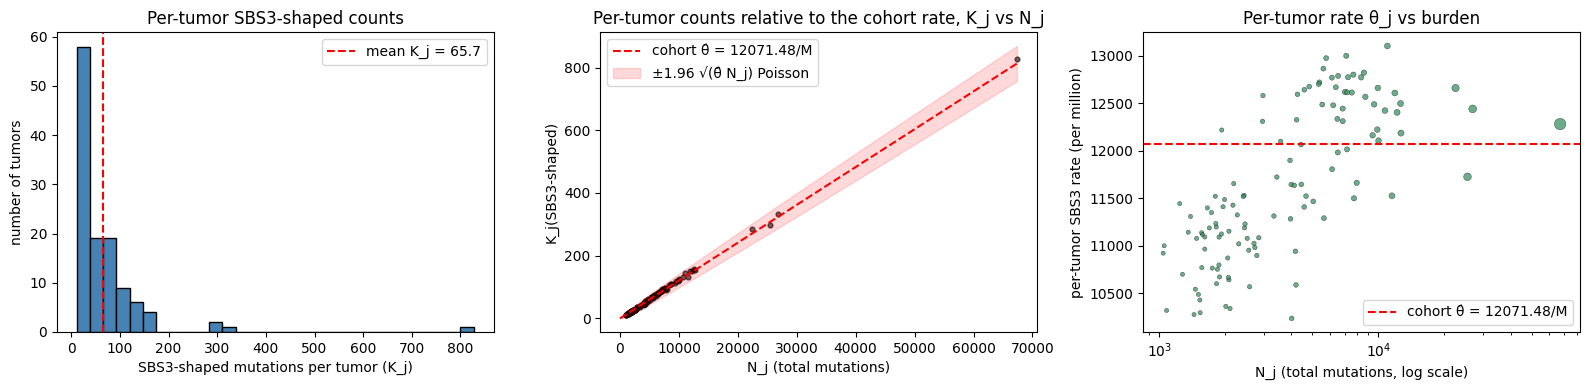

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# left: hist of simulated per-tumor K_j
axes[0].hist(K_per_sample, bins=30, color='steelblue', edgecolor='black')
axes[0].axvline(K_per_sample.mean(), color='red', linestyle='--', label=f'mean K_j = {K_per_sample.mean():.1f}')
axes[0].set_xlabel('SBS3-shaped mutations per tumor (K_j)')
axes[0].set_ylabel('number of tumors')
axes[0].set_title('Per-tumor SBS3-shaped counts')
axes[0].legend()

# middle: NEW NAME
N_grid = np.linspace(0, N_per_sample.max(), 100)
mean_line = N_grid * theta_hat
band = 1.96 * np.sqrt(theta_hat * N_grid)
axes[1].scatter(N_per_sample, K_per_sample, s=12, color='black', alpha=0.6)
axes[1].plot(N_grid, mean_line, color='red', linestyle='--',
             label=f'cohort θ̂ = {theta_hat*1e6:.2f}/M')
axes[1].fill_between(N_grid, mean_line - band, mean_line + band,
                     color='red', alpha=0.15, label='±1.96 √(θ̂ N_j) Poisson')
axes[1].set_xlabel('N_j (total mutations)')
axes[1].set_ylabel('K_j(SBS3-shaped)')
axes[1].set_title('Per-tumor counts relative to the cohort rate, K_j vs N_j')
axes[1].legend()

# right: Per-tumor rate
sizes = 8 + 60 * (N_per_sample / N_per_sample.max())
axes[2].scatter(N_per_sample, theta_per_sample * 1e6, s=sizes, color='seagreen', alpha=0.7, edgecolor='black', linewidth=0.3)
axes[2].axhline(theta_hat * 1e6, color='red', linestyle='--', label=f'cohort θ̂ = {theta_hat*1e6:.2f}/M')
axes[2].set_xscale('log')
axes[2].set_xlabel('N_j (total mutations, log scale)')
axes[2].set_ylabel('per-tumor SBS3 rate (per million)')
axes[2].set_title('Per-tumor rate θ_j vs burden')
axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
print(f"n_tumors              = {n_tumors}")
print(f"cohort θ̂              = {theta_hat:.4e}  "
      f"({theta_hat*1e6:.3f} per million)")
print(f"per-tumour θ_j: mean  = {theta_per_sample.mean()*1e6:.3f} per million")
print(f"per-tumour θ_j: std   = {theta_per_sample.std()*1e6:.3f} per million")
print(f"per-tumour θ_j: min   = {theta_per_sample.min()*1e6:.3f} per million")
print(f"per-tumour θ_j: max   = {theta_per_sample.max()*1e6:.3f} per million")

n_tumors              = 119
cohort θ̂              = 1.2071e-02  (12071.484 per million)
per-tumour θ_j: mean  = 11645.406 per million
per-tumour θ_j: std   = 785.235 per million
per-tumour θ_j: min   = 10234.774 per million
per-tumour θ_j: max   = 13103.778 per million


## Model limitations — how it breaks

1. **Projection ≠ count.** $K = r_{\text{SBS3}}^\top c$ is a weighted sum,
   not an integer count.
   - $K_{\text{total}}$-$K_{int}$

2. **Underdispersion (Poisson CI too wide)** Per-tumor $θ_j$ spans 10234–13104 per million and the Bootstrap/Poisson SE ratio = 0.48x. Both indicate the observed spread is narrower than homogenous-Poisson sampling predicts. The observed variance is below the mean at the count level while the Poisson model assumes variance = mean, so the Poisson-implied CI is conservative by a factor of 1/0.48 = 2.08x. Explanation: a) genuine underdispersion of SBS3-shaped counts across tumors, b) ratio-estimator cancellation because $\hatθ$ = sum of K / sum of N and negative K-N correlation shrinks the sampling variance of the pooled ratio.
  - Distinction between explanations can be done with a hierarchichal fit.

3. **Collapsed heterogeneity.** A single θ averages over a possible BRCA1/2-associated subpopulation that the paper documents. On this dataset the residual spread is smaller than Poisson predicts (see above), so collapsing to one θ does not inflate the uncertainty of the pooled rate — but it does hide possible mean structure: if BRCA1/2 and non-BRCA1/2 tumours have different true θ, the pooled estimate is a burden-weighted average that is not equal to either subgroup's rate. Detecting this requires a hierarchical / mixture fit, not a wider CI.
   - Spread of $θ_j$ = 785.235 per million, range = 10234-13104 per million

4. **Conditioning on N.** Fixing N ignores covariation between burden and signature fraction — visible in the $K_j$ vs $N_j$ scatter.

5. **No full model comparison.** We test Poisson against the empirical
   spread (bootstrap), but not against a fitted negative
   binomial. We could also fit a hierarchical/mixture model for BRCA1 subpopulations. That would be the natural next step.